# Machine Learning Algorithms — Online Shoppers Intention

| Section | Content |
|---|---|
| 1 | Load & Preprocess |
| 2 | K-Fold & GridSearchCV — explained |
| 3 | Logistic Regression (No Reg / L1 / L2) |
| 4 | SVM (Linear / RBF) |
| 5 | Decision Tree |
| 6 | Random Forest |
| 7 | XGBoost |
| 8 | K-Nearest Neighbours (KNN) |
| 9 | Overall Comparison |
| 10 | PCA on Best Performing Algorithms |


---
## 1. Imports & Setup

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model  import LogisticRegression
from sklearn.svm           import SVC
from sklearn.tree          import DecisionTreeClassifier, plot_tree
from sklearn.ensemble      import RandomForestClassifier
from sklearn.neighbors     import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
    print('XGBoost available.')
except ImportError:
    print('XGBoost not found — run: pip install xgboost')

import warnings
warnings.filterwarnings('ignore')
print('All libraries loaded.')


XGBoost available.
All libraries loaded.


In [47]:
pip install XGBoost

Note: you may need to restart the kernel to use updated packages.


---
## 2. Load & Preprocess Data

In this step, the dataset is loaded into a pandas DataFrame for inspection and analysis.

This allows us to explore the structure of the data, identify feature types, and prepare it for preprocessing.

In [11]:
df = pd.read_csv('online_shoppers_intention.csv')

In [13]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [15]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [17]:
df.shape

(12330, 18)

### Initial Data Exploration

The dataset preview, summary statistics, and shape help us understand:
- the number of samples and features
- the general distribution of numerical variables
- whether further cleaning is needed

This step is important because understanding the dataset comes before building reliable models.

In [19]:
df = df.drop_duplicates()
print('Shape after deduplication:', df.shape)
df.head()

Shape after deduplication: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Why Remove Duplicates?

Duplicate records can bias model training by over-representing certain patterns.

By removing duplicates, we ensure that the dataset better reflects unique user sessions and improves the reliability of model evaluation.

In [21]:
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print('Feature matrix shape :', X.shape)
print('Target distribution   :')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Feature matrix shape : (12205, 26)
Target distribution   :
Revenue
0    10297
1     1908
Name: count, dtype: int64
Revenue
0    0.844
1    0.156
Name: proportion, dtype: float64


### Separating Features and Target

The dataset is divided into:
- `X`: input features used for prediction
- `y`: target variable (`Revenue`)

This is necessary because the model learns patterns in the input features to predict whether a customer makes a purchase.

In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12205 non-null  int64  
 1   Administrative_Duration        12205 non-null  float64
 2   Informational                  12205 non-null  int64  
 3   Informational_Duration         12205 non-null  float64
 4   ProductRelated                 12205 non-null  int64  
 5   ProductRelated_Duration        12205 non-null  float64
 6   BounceRates                    12205 non-null  float64
 7   ExitRates                      12205 non-null  float64
 8   PageValues                     12205 non-null  float64
 9   SpecialDay                     12205 non-null  float64
 10  OperatingSystems               12205 non-null  int64  
 11  Browser                        12205 non-null  int64  
 12  Region                         12205 non-null  int6

In [25]:
# ── Train / Test split (stratified) ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Scaling (fit on train ONLY, then transform both) ─────────────────────────
# Required for LR and SVM.  Tree-based models don't need it but it won't hurt.
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print('X_train:', X_train_sc.shape, ' | X_test:', X_test_sc.shape)
print('Feature names stored for later use.')
feature_names = X.columns.tolist()

X_train: (9764, 26)  | X_test: (2441, 26)
Feature names stored for later use.


### Train-Test Split and Scaling

A stratified train-test split was used to preserve the class distribution of the target variable.

This is especially important because the dataset is imbalanced, with far fewer buyers than non-buyers.

Feature scaling was also applied to standardise the data. This helps many machine learning models perform more effectively, especially distance-based and margin-based models.

In [27]:
print("Mean of features:", np.mean(X_train_sc, axis=0))
print("Std of features:", np.std(X_train_sc, axis=0))

Mean of features: [-1.45543371e-17 -7.82295618e-17 -1.16434697e-17 -3.31111168e-17
  1.34627618e-17  5.82173483e-17  3.05641078e-17 -2.18315056e-18
  5.05763213e-17  1.81929213e-17 -1.60097708e-16  5.82173483e-17
 -1.01516501e-16 -8.73260224e-18  3.71135595e-17  2.18315056e-17
  2.18315056e-18  8.00488539e-18 -1.17890130e-16 -9.09646067e-18
  2.32869393e-17 -9.09646067e-19 -7.27716854e-18 -4.85751000e-17
 -1.46998804e-16 -3.67497011e-17]
Std of features: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]


In [29]:
print("Original distribution:")
print(pd.Series(y).value_counts(normalize=True))

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nTest distribution:")
print(pd.Series(y_test).value_counts(normalize=True))

Original distribution:
Revenue
0    0.843671
1    0.156329
Name: proportion, dtype: float64

Train distribution:
Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64

Test distribution:
Revenue
0    0.843507
1    0.156493
Name: proportion, dtype: float64


### Class Imbalance

The dataset contains many more non-buyers than buyers.

This means that accuracy alone is not enough to judge performance, because a model could appear accurate simply by predicting the majority class.

From a business perspective, correctly identifying buyers is more important because they directly contribute to revenue.

---
## 3. K-Fold Cross-Validation & GridSearchCV — How They Work

### K-Fold CV
A single train/test split can be lucky or unlucky. **Stratified K-Fold** repeats training+evaluation `k` times, rotating which slice is held out each time:

```
Fold 1: [TEST ][train][train][train][train]  → score_1
Fold 2: [train][TEST ][train][train][train]  → score_2
Fold 3: [train][train][TEST ][train][train]  → score_3
Fold 4: [train][train][train][TEST ][train]  → score_4
Fold 5: [train][train][train][train][TEST ]  → score_5
                                               mean ± std  ← reported score
```

**Stratified** = each fold keeps the same ~85/15 class ratio as the original data.

### GridSearchCV
Tries every combination of hyperparameters you specify, evaluates each with K-Fold internally, returns the best:
```
C=[0.1, 1, 10]  x  gamma=['scale','auto']  =  6 combinations
each combination x 5 folds  =  30 model fits  →  picks winner
```

### Why F1 not Accuracy?
~85% of shoppers do NOT buy. A model that always predicts No Purchase scores **85% accuracy** but is completely useless. F1 balances Precision and Recall, so it penalises that lazy behaviour.

In [57]:
# Shared splitter — same folds used for every model (fair comparison)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Results registry — populated as we go
results = {}

def full_evaluation(name, model, X_tr, y_tr, X_te, y_te, store=True):
    """
    1. K-Fold CV on the training set
    2. Final fit on full training set
    3. Evaluation on held-out test set
    """
    # K-Fold CV
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='f1')

    # Final fit + test prediction
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    f1     = f1_score(y_te, y_pred)

    print(f"\n{'='*62}")
    print(f"  {name}")
    print(f"{'='*62}")
    print(f"  K-Fold CV F1  : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
    print(f"  Per-fold F1   : {[round(s,3) for s in cv_scores]}")
    print(f"  Test Accuracy : {acc:.4f}")
    print(f"  Test F1       : {f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=['No Purchase','Purchase']))

    if store:
        results[name] = {
            'model'    : model,
            'y_pred'   : y_pred,
            'cv_f1'    : cv_scores.mean(),
            'test_acc' : acc,
            'test_f1'  : f1,
        }
    return model, y_pred, acc, f1

---
## 4. Logistic Regression

Logistic Regression is used as a baseline classification model.

It is simple, interpretable, and useful for comparing the performance of more advanced algorithms.

Different regularisation methods are tested to reduce overfitting and improve generalisation. ones.

### 4.1 No Regularization
No penalty — coefficients are unconstrained. Useful baseline. No hyperparameters to grid-search.

In [9]:
lr_noreg, pred_noreg, acc_noreg, f1_noreg = full_evaluation(
    'LR — No Reg',
    LogisticRegression(penalty=None, max_iter=2000, random_state=42,
                       class_weight='balanced', solver='lbfgs'),
    X_train_sc, y_train, X_test_sc, y_test
)


  LR — No Reg
  K-Fold CV F1  : 0.6200  ±  0.0243
  Per-fold F1   : [np.float64(0.618), np.float64(0.579), np.float64(0.624), np.float64(0.625), np.float64(0.655)]
  Test Accuracy : 0.8513
  Test F1       : 0.6231

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.91      2059
    Purchase       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.82      0.77      2441
weighted avg       0.89      0.85      0.86      2441



### 4.2 L1 Regularization — GridSearchCV over C
Penalty = Σ|wᵢ| → drives irrelevant feature coefficients to exactly **zero** (feature selection).

In [10]:
grid_l1 = GridSearchCV(
    LogisticRegression(penalty='l1', max_iter=2000, random_state=42,
                       class_weight='balanced', solver='liblinear'),
    param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=skf, scoring='f1', n_jobs=-1
)
grid_l1.fit(X_train_sc, y_train)
print(f'Best C: {grid_l1.best_params_["C"]}  |  Best CV F1: {grid_l1.best_score_:.4f}')

lr_l1, pred_l1, acc_l1, f1_l1 = full_evaluation(
    'LR — L1',
    grid_l1.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)
print(f'Coefficients zeroed by L1: {np.sum(lr_l1.coef_[0]==0)} / {len(lr_l1.coef_[0])}')

Best C: 0.001  |  Best CV F1: 0.6557

  LR — L1
  K-Fold CV F1  : 0.6557  ±  0.0121
  Per-fold F1   : [np.float64(0.637), np.float64(0.651), np.float64(0.663), np.float64(0.674), np.float64(0.654)]
  Test Accuracy : 0.8865
  Test F1       : 0.6634

              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.93      2059
    Purchase       0.62      0.71      0.66       382

    accuracy                           0.89      2441
   macro avg       0.78      0.82      0.80      2441
weighted avg       0.89      0.89      0.89      2441

Coefficients zeroed by L1: 25 / 26


### 4.3 L2 Regularization — GridSearchCV over C
Penalty = Σwᵢ² → shrinks all coefficients but never to exactly zero.

In [11]:
grid_l2 = GridSearchCV(
    LogisticRegression(penalty='l2', max_iter=2000, random_state=42,
                       class_weight='balanced', solver='lbfgs'),
    param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=skf, scoring='f1', n_jobs=-1
)
grid_l2.fit(X_train_sc, y_train)
print(f'Best C: {grid_l2.best_params_["C"]}  |  Best CV F1: {grid_l2.best_score_:.4f}')

lr_l2, pred_l2, acc_l2, f1_l2 = full_evaluation(
    'LR — L2',
    grid_l2.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

Best C: 100  |  Best CV F1: 0.6200

  LR — L2
  K-Fold CV F1  : 0.6200  ±  0.0243
  Per-fold F1   : [np.float64(0.618), np.float64(0.579), np.float64(0.624), np.float64(0.625), np.float64(0.655)]
  Test Accuracy : 0.8513
  Test F1       : 0.6231

              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.91      2059
    Purchase       0.52      0.79      0.62       382

    accuracy                           0.85      2441
   macro avg       0.74      0.82      0.77      2441
weighted avg       0.89      0.85      0.86      2441



### Logistic Regression Interpretation

Among the Logistic Regression variants, regularised models performed better because they reduce the influence of less important features.

This is especially useful after one-hot encoding, where the number of features increases.

From a business perspective, this model provides a clear baseline, but may not capture more complex user behaviour patterns.

### Logistic Regression — Visuals

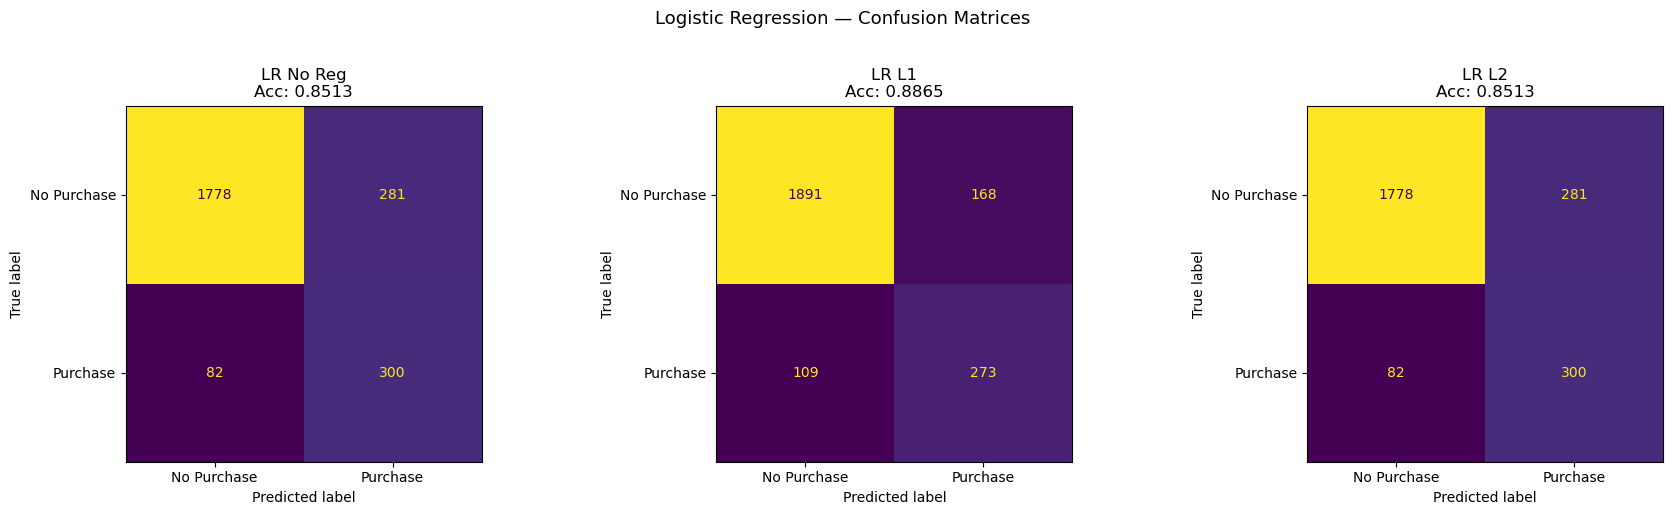

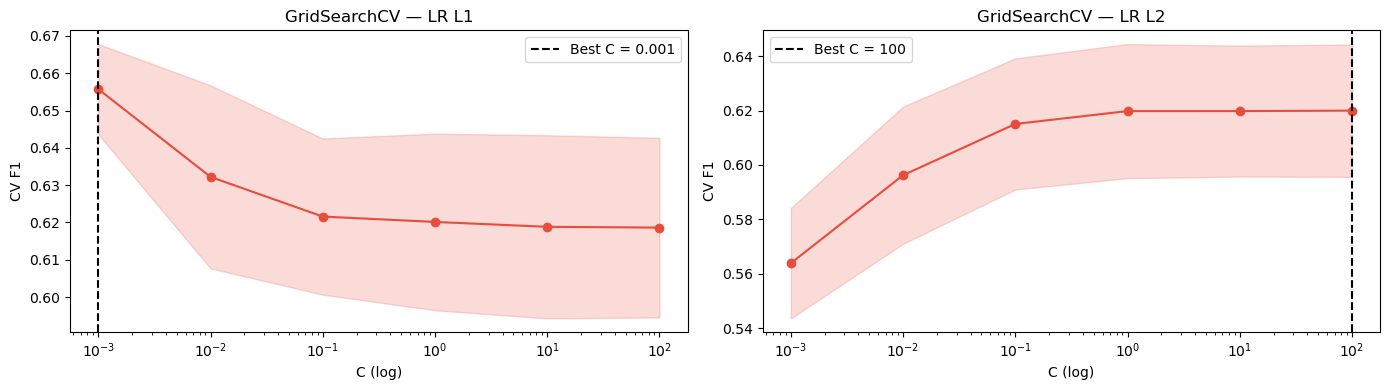

In [12]:
lr_names  = ['No Reg', 'L1', 'L2']
lr_models = [lr_noreg, lr_l1, lr_l2]
lr_preds  = [pred_noreg, pred_l1, pred_l2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, pred in zip(axes, lr_names, lr_preds):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['No Purchase','Purchase']
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f'LR {name}\nAcc: {accuracy_score(y_test,pred):.4f}')
plt.suptitle('Logistic Regression — Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# GridSearchCV tuning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, name, grid in zip(axes, ['L1','L2'], [grid_l1, grid_l2]):
    res   = pd.DataFrame(grid.cv_results_)
    c_val = res['param_C'].astype(float)
    ax.plot(c_val, res['mean_test_score'], marker='o', color='#e74c3c')
    ax.fill_between(c_val,
                    res['mean_test_score'] - res['std_test_score'],
                    res['mean_test_score'] + res['std_test_score'],
                    alpha=0.2, color='#e74c3c')
    ax.axvline(grid.best_params_['C'], color='black', linestyle='--',
               label=f"Best C = {grid.best_params_['C']}")
    ax.set_xscale('log'); ax.set_xlabel('C (log)'); ax.set_ylabel('CV F1')
    ax.set_title(f'GridSearchCV — LR {name}'); ax.legend()
plt.tight_layout(); plt.show()

### Business Interpretation of the Confusion Matrix

The confusion matrix shows how well the model distinguishes buyers from non-buyers.

- False Negatives mean actual buyers were missed
- False Positives mean non-buyers were targeted unnecessarily

In this business problem, false negatives are especially costly because they represent lost sales opportunities.

---
## 5. Support Vector Machine (SVM)

SVM attempts to separate classes using an optimal decision boundary.

Both linear and RBF kernels are tested to compare simple and non-linear separation.

This helps determine whether user purchase behaviour is better captured using more flexible boundaries.

### 5.1 Linear Kernel
Finds the hyperplane that maximises the gap (margin) between the two classes in the original feature space.

In [67]:
grid_svm_lin = GridSearchCV(
    SVC(kernel='linear', random_state=42, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_svm_lin.fit(X_train_sc, y_train)
print(f'Best C: {grid_svm_lin.best_params_["C"]}  |  Best CV F1: {grid_svm_lin.best_score_:.4f}')

svm_lin, pred_svm_lin, acc_svm_lin, f1_svm_lin = full_evaluation(
    'SVM — Linear',
    grid_svm_lin.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best C: 0.1  |  Best CV F1: 0.6533

  SVM — Linear
  K-Fold CV F1  : 0.6533  ±  0.0200
  Per-fold F1   : [0.64, 0.631, 0.648, 0.689, 0.659]
  Test Accuracy : 0.8751
  Test F1       : 0.6554

              precision    recall  f1-score   support

 No Purchase       0.95      0.90      0.92      2059
    Purchase       0.58      0.76      0.66       382

    accuracy                           0.88      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.88      0.88      2441



### 5.2 RBF Kernel
Maps data to a high-dimensional space where non-linear boundaries become separable. Two params: `C` (margin penalty) and `gamma` (influence radius per point).

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'C': 10, 'gamma': 0.001}  |  Best CV F1: 0.6577


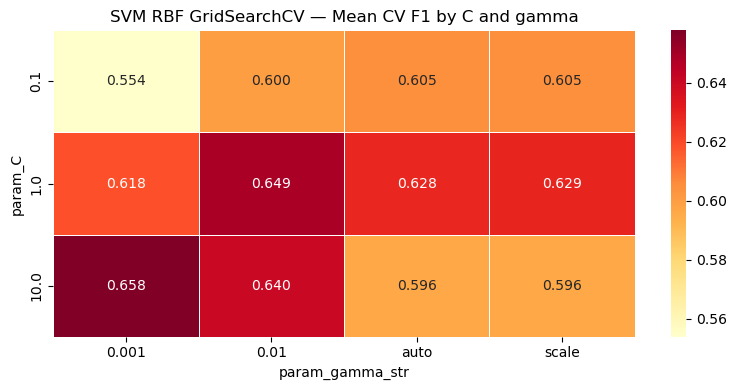


  SVM — RBF
  K-Fold CV F1  : 0.6577  ±  0.0228
  Per-fold F1   : [np.float64(0.642), np.float64(0.632), np.float64(0.644), np.float64(0.688), np.float64(0.683)]
  Test Accuracy : 0.8816
  Test F1       : 0.6690

              precision    recall  f1-score   support

 No Purchase       0.95      0.90      0.93      2059
    Purchase       0.59      0.76      0.67       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.80      2441
weighted avg       0.90      0.88      0.89      2441



In [14]:
grid_svm_rbf = GridSearchCV(
    SVC(kernel='rbf', random_state=42, class_weight='balanced'),
    param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.001]},
    cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_svm_rbf.fit(X_train_sc, y_train)
print(f'Best params: {grid_svm_rbf.best_params_}  |  Best CV F1: {grid_svm_rbf.best_score_:.4f}')

# Heatmap
rbf_res = pd.DataFrame(grid_svm_rbf.cv_results_)
rbf_res['param_gamma_str'] = rbf_res['param_gamma'].astype(str)
pivot = rbf_res.pivot_table(index='param_C', columns='param_gamma_str', values='mean_test_score')
plt.figure(figsize=(8,4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('SVM RBF GridSearchCV — Mean CV F1 by C and gamma')
plt.tight_layout(); plt.show()

svm_rbf, pred_svm_rbf, acc_svm_rbf, f1_svm_rbf = full_evaluation(
    'SVM — RBF',
    grid_svm_rbf.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

### SVM Interpretation

The RBF kernel performed better than the linear kernel, suggesting that the relationship between features and purchase behaviour is not purely linear.

This makes SVM useful for capturing more complex behaviour, although it is more computationally expensive.

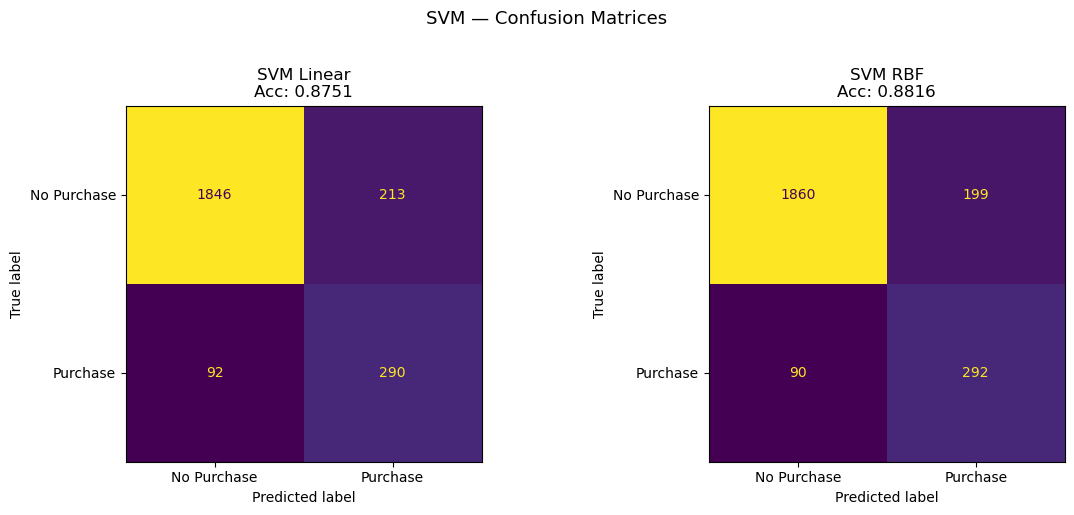

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, pred in zip(axes, ['Linear','RBF'], [pred_svm_lin, pred_svm_rbf]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred), display_labels=['No Purchase','Purchase']
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f'SVM {name}\nAcc: {accuracy_score(y_test,pred):.4f}')
plt.suptitle('SVM — Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 6. Decision Tree

A Decision Tree splits the data at each node by choosing the feature and threshold that best separates the classes (using **Gini impurity** or **entropy**). It keeps splitting until a stopping condition is met. 

They are useful because they are easy to interpret and allow us to visualise how predictions are made.

```
                [PageValues <= 3.5?]
               /                    \
         [YES]                        [NO]
    [BounceRate <= 0.02?]         → Predict: Purchase
       /         \
  [YES]           [NO]
  → No Purchase  → Purchase
```

**Key hyperparameters:**
- `max_depth` — how many levels deep the tree can grow (prevents overfitting)
- `min_samples_split` — minimum samples needed to split a node
- `criterion` — how split quality is measured (gini or entropy)

In [16]:
print('=== Decision Tree — GridSearchCV ===')

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid={
        'max_depth'        : [3, 5, 10, 15, None],
        'min_samples_split': [2, 10, 20],
        'criterion'        : ['gini', 'entropy']
    },
    cv=skf, scoring='f1', n_jobs=-1, verbose=0
)
grid_dt.fit(X_train_sc, y_train)
print(f'Best params : {grid_dt.best_params_}')
print(f'Best CV F1  : {grid_dt.best_score_:.4f}')

dt, pred_dt, acc_dt, f1_dt = full_evaluation(
    'Decision Tree',
    grid_dt.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

=== Decision Tree — GridSearchCV ===
Best params : {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV F1  : 0.6306

  Decision Tree
  K-Fold CV F1  : 0.6306  ±  0.0104
  Per-fold F1   : [np.float64(0.627), np.float64(0.645), np.float64(0.639), np.float64(0.625), np.float64(0.616)]
  Test Accuracy : 0.8476
  Test F1       : 0.6388

              precision    recall  f1-score   support

 No Purchase       0.97      0.85      0.90      2059
    Purchase       0.51      0.86      0.64       382

    accuracy                           0.85      2441
   macro avg       0.74      0.85      0.77      2441
weighted avg       0.90      0.85      0.86      2441



### Decision Tree Interpretation

The Decision Tree achieved high recall, meaning it identified many buyers.

However, its lower precision means that it also produced more false positives.

From a business perspective, this could increase the number of users targeted with promotions, including users who may not actually convert.

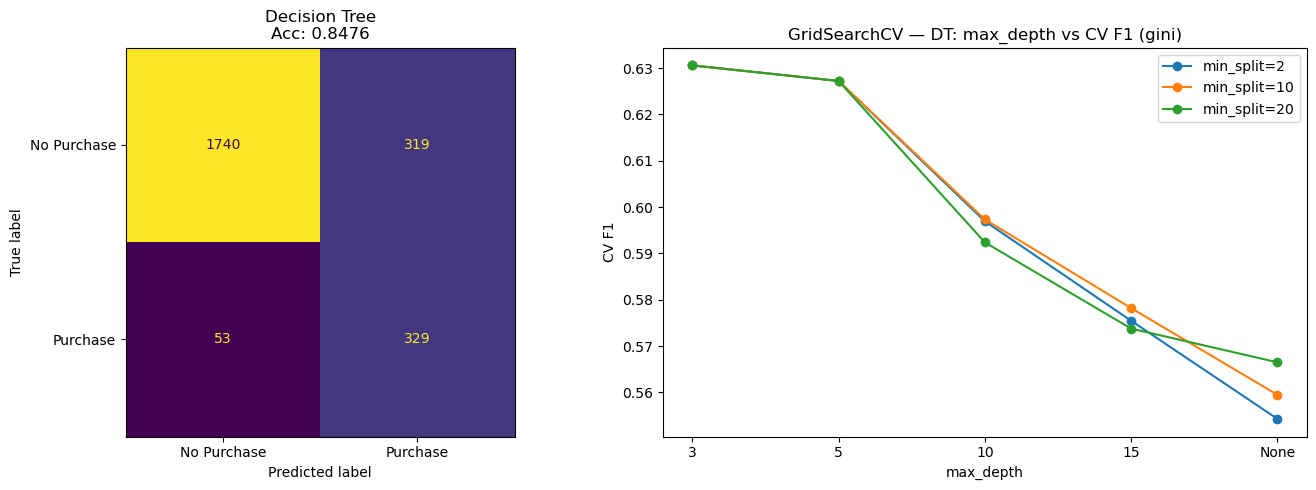

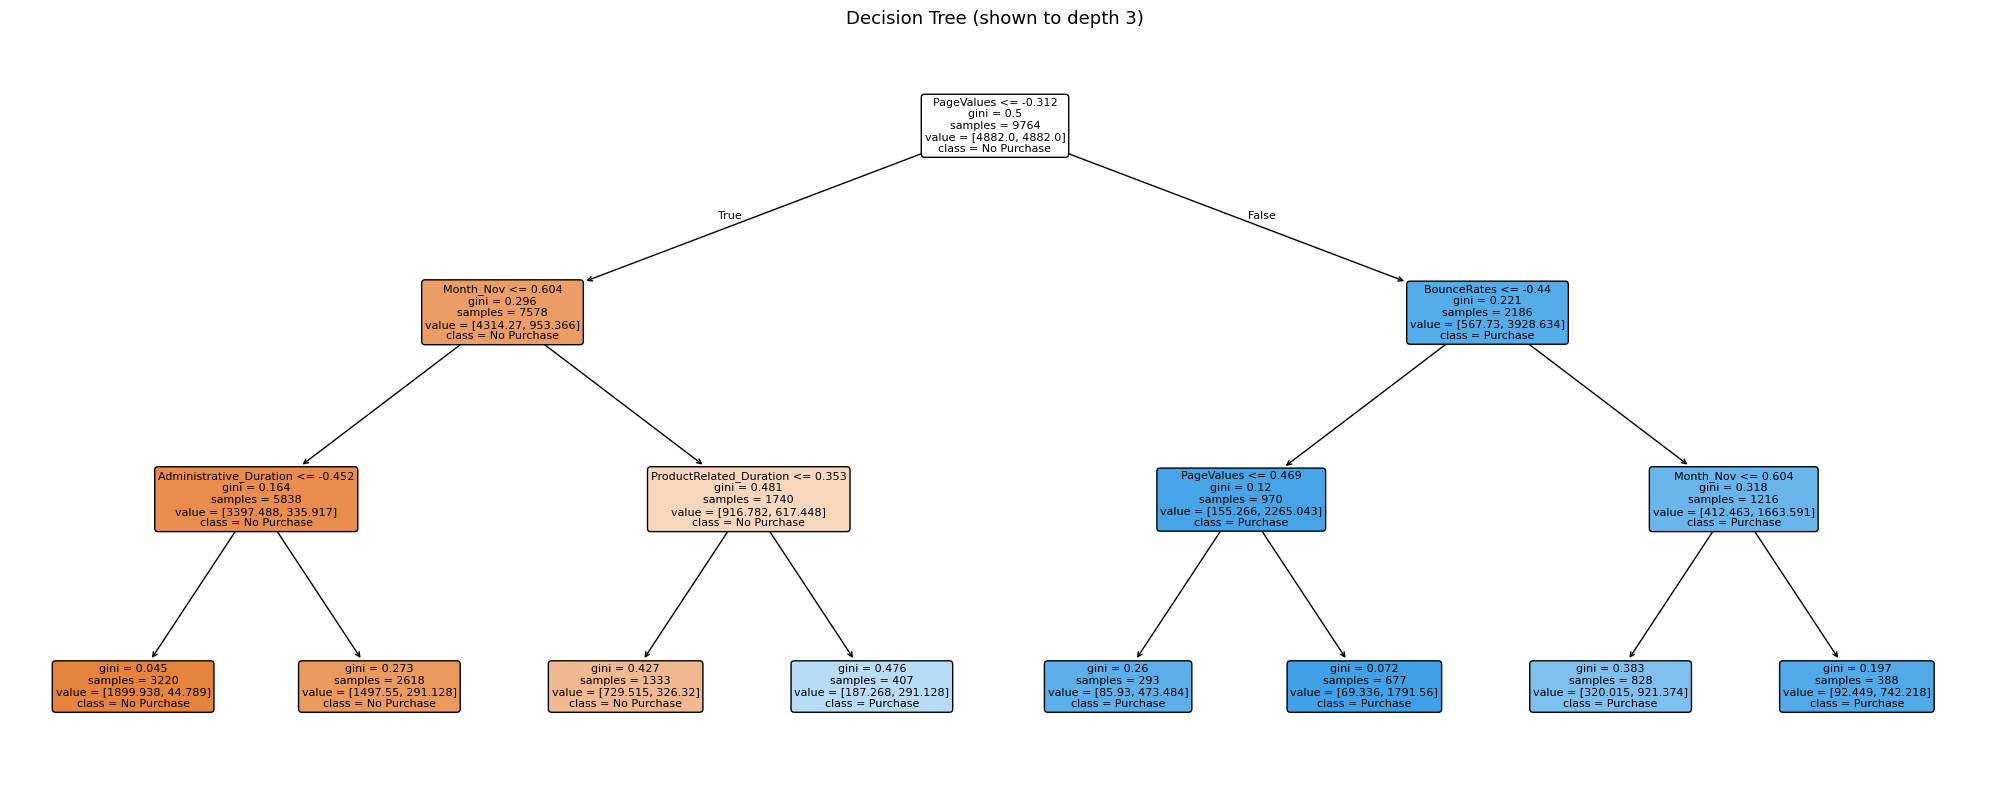

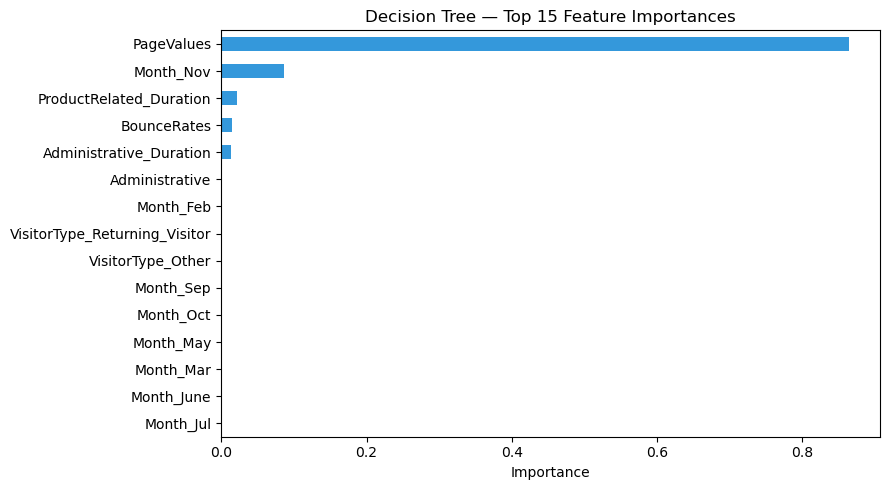

In [17]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_dt), display_labels=['No Purchase','Purchase']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Decision Tree\nAcc: {acc_dt:.4f}')

# GridSearchCV: max_depth vs CV F1 (gini only for clarity)
res_dt = pd.DataFrame(grid_dt.cv_results_)
res_gini = res_dt[res_dt['param_criterion']=='gini'].copy()
for mss, grp in res_gini.groupby('param_min_samples_split'):
    grp_sorted = grp.sort_values('param_max_depth')
    axes[1].plot(
        grp_sorted['param_max_depth'].astype(str),
        grp_sorted['mean_test_score'],
        marker='o', label=f'min_split={mss}'
    )
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('CV F1')
axes[1].set_title('GridSearchCV — DT: max_depth vs CV F1 (gini)')
axes[1].legend()
plt.tight_layout(); plt.show()

# Visualise the tree (capped at depth 3 for readability)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt, max_depth=3, feature_names=feature_names,
    class_names=['No Purchase','Purchase'],
    filled=True, rounded=True, ax=ax, fontsize=8
)
plt.title('Decision Tree (shown to depth 3)', fontsize=13)
plt.tight_layout(); plt.show()

# Top 15 feature importances
fi_dt = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
fi_dt.plot(kind='barh', ax=ax, color='#3498db')
ax.invert_yaxis()
ax.set_title('Decision Tree — Top 15 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

---
## 7. Random Forest

Random Forest builds **many decision trees** (an ensemble) and combines their votes. Each tree is trained on a **random bootstrap sample** of the data, and at each split it considers only a **random subset of features**. This controlled randomness makes the individual trees different from each other — averaging diverse trees reduces variance and prevents overfitting.

```
Training data ──► Bootstrap sample 1 ──► Tree 1 ──► Vote
               ──► Bootstrap sample 2 ──► Tree 2 ──► Vote  ──► Majority vote → Final prediction
               ──► Bootstrap sample N ──► Tree N ──► Vote
```

**Key hyperparameters:**
- `n_estimators` — number of trees (more = better but slower)
- `max_depth` — depth limit per tree
- `max_features` — how many features to consider at each split

In [18]:
print('=== Random Forest — GridSearchCV ===')

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth'   : [5, 10, None],
        'max_features': ['sqrt', 'log2']
    },
    cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_sc, y_train)
print(f'\nBest params : {grid_rf.best_params_}')
print(f'Best CV F1  : {grid_rf.best_score_:.4f}')

rf, pred_rf, acc_rf, f1_rf = full_evaluation(
    'Random Forest',
    grid_rf.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

=== Random Forest — GridSearchCV ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params : {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV F1  : 0.6741

  Random Forest
  K-Fold CV F1  : 0.6741  ±  0.0141
  Per-fold F1   : [np.float64(0.663), np.float64(0.662), np.float64(0.673), np.float64(0.701), np.float64(0.672)]
  Test Accuracy : 0.8816
  Test F1       : 0.6771

              precision    recall  f1-score   support

 No Purchase       0.96      0.90      0.93      2059
    Purchase       0.59      0.79      0.68       382

    accuracy                           0.88      2441
   macro avg       0.77      0.85      0.80      2441
weighted avg       0.90      0.88      0.89      2441



### Random Forest Interpretation

Random Forest achieved one of the strongest overall results, with a good balance between precision, recall, and F1-score.

This makes it more practical for real-world business use, where both identifying buyers and avoiding excessive false positives are important.

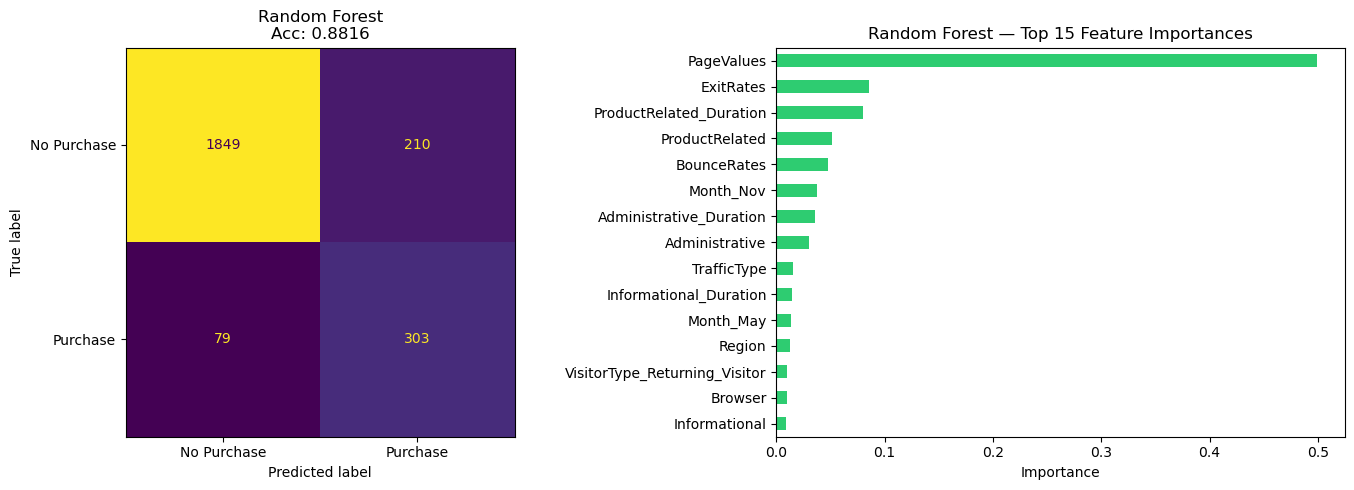

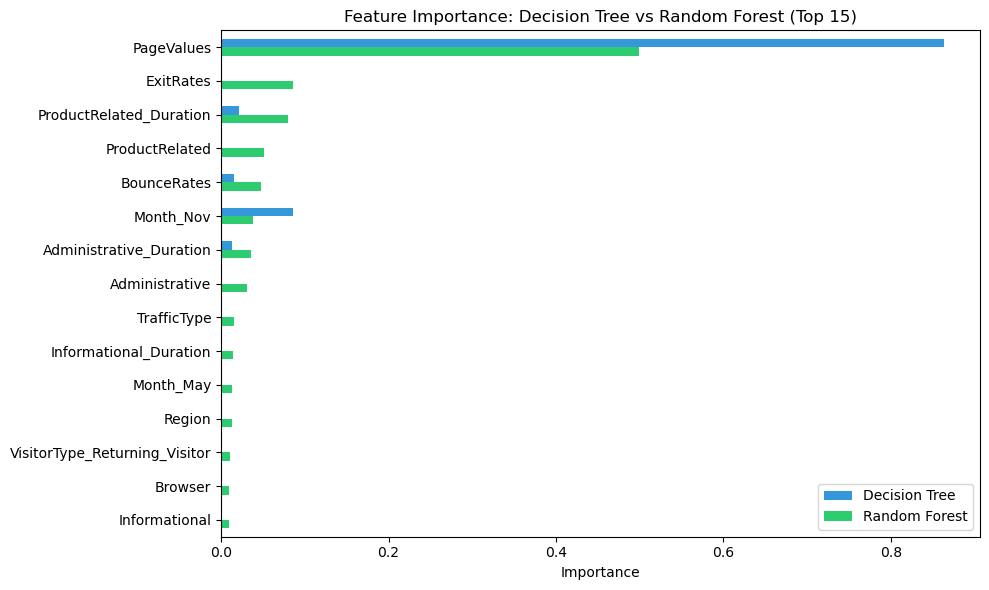

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_rf), display_labels=['No Purchase','Purchase']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Random Forest\nAcc: {acc_rf:.4f}')

# Top 15 feature importances
fi_rf = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
fi_rf.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].invert_yaxis()
axes[1].set_title('Random Forest — Top 15 Feature Importances')
axes[1].set_xlabel('Importance')
plt.tight_layout(); plt.show()

# DT vs RF feature importance comparison
fi_compare = pd.DataFrame({
    'Decision Tree' : pd.Series(dt.feature_importances_, index=feature_names),
    'Random Forest' : pd.Series(rf.feature_importances_, index=feature_names)
}).sort_values('Random Forest', ascending=False).head(15)

fi_compare.plot(kind='barh', figsize=(10, 6), color=['#3498db','#2ecc71'])
plt.gca().invert_yaxis()
plt.title('Feature Importance: Decision Tree vs Random Forest (Top 15)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

---
## 8. XGBoost (Extreme Gradient Boosting)

XGBoost is also an ensemble of trees, but built **sequentially** instead of in parallel. Each new tree is trained to correct the errors (residuals) of all the previous trees combined — this is **gradient boosting**.

```
Tree 1  →  residuals_1
Tree 2 trained on residuals_1  →  residuals_2
Tree 3 trained on residuals_2  →  residuals_3
...
Final prediction = weighted sum of all trees
```

**Key hyperparameters:**
- `n_estimators` — number of boosting rounds
- `max_depth` — depth per tree (shallower = less overfit)
- `learning_rate` — how much each tree contributes (smaller = more careful)
- `scale_pos_weight` — handles class imbalance (set to ratio of negatives/positives)

In [20]:
print('=== XGBoost — GridSearchCV ===')

# scale_pos_weight compensates for class imbalance
neg_pos_ratio = int((y_train == 0).sum() / (y_train == 1).sum())
print(f'scale_pos_weight set to: {neg_pos_ratio}')

grid_xgb = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=neg_pos_ratio,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_grid={
        'n_estimators'  : [100, 200],
        'max_depth'     : [3, 5, 7],
        'learning_rate' : [0.05, 0.1, 0.2]
    },
    cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train_sc, y_train)
print(f'\nBest params : {grid_xgb.best_params_}')
print(f'Best CV F1  : {grid_xgb.best_score_:.4f}')

xgb, pred_xgb, acc_xgb, f1_xgb = full_evaluation(
    'XGBoost',
    grid_xgb.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

=== XGBoost — GridSearchCV ===
scale_pos_weight set to: 5
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params : {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Best CV F1  : 0.6739

  XGBoost
  K-Fold CV F1  : 0.6739  ±  0.0141
  Per-fold F1   : [np.float64(0.653), np.float64(0.68), np.float64(0.663), np.float64(0.693), np.float64(0.68)]
  Test Accuracy : 0.8746
  Test F1       : 0.6615

              precision    recall  f1-score   support

 No Purchase       0.96      0.89      0.92      2059
    Purchase       0.57      0.78      0.66       382

    accuracy                           0.87      2441
   macro avg       0.76      0.84      0.79      2441
weighted avg       0.90      0.87      0.88      2441



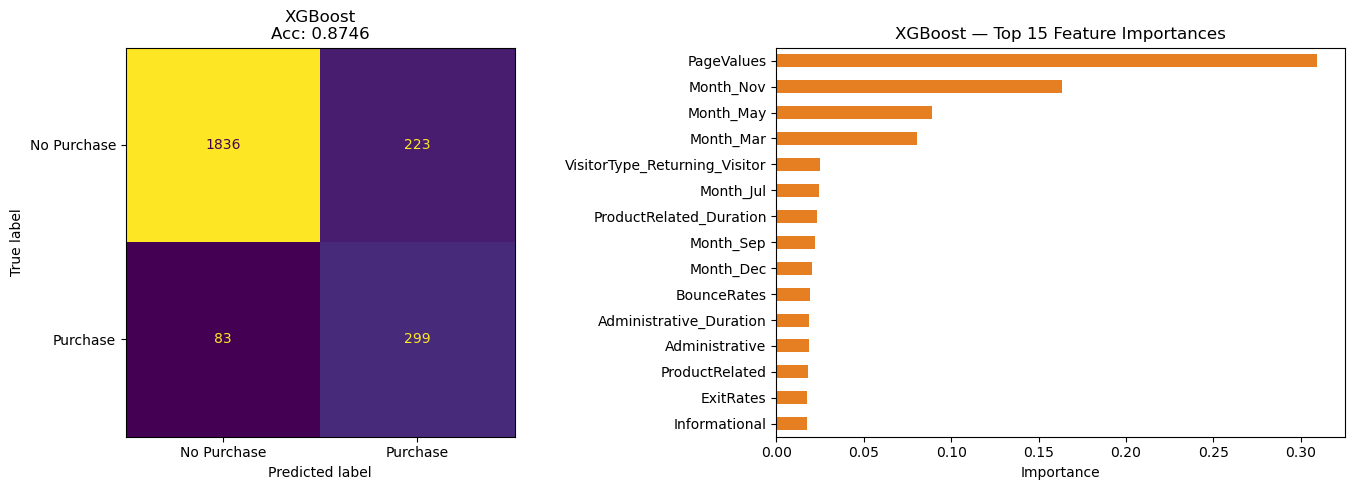

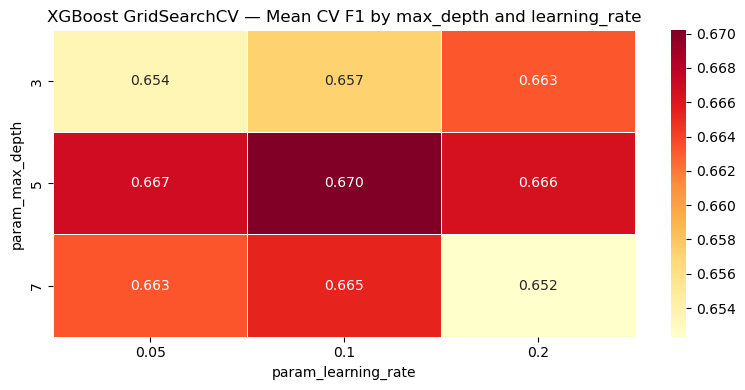

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_xgb), display_labels=['No Purchase','Purchase']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'XGBoost\nAcc: {acc_xgb:.4f}')

# Feature importances
fi_xgb = pd.Series(xgb.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
fi_xgb.plot(kind='barh', ax=axes[1], color='#e67e22')
axes[1].invert_yaxis()
axes[1].set_title('XGBoost — Top 15 Feature Importances')
axes[1].set_xlabel('Importance')
plt.tight_layout(); plt.show()

# Learning rate vs CV F1 heatmap
xgb_res = pd.DataFrame(grid_xgb.cv_results_)
pivot_xgb = xgb_res.pivot_table(
    index='param_max_depth', columns='param_learning_rate', values='mean_test_score'
)
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_xgb, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)
plt.title('XGBoost GridSearchCV — Mean CV F1 by max_depth and learning_rate')
plt.tight_layout(); plt.show()

### Why Hyperparameter Tuning Matters

The heatmap shows how different combinations of parameters affect model performance.

By selecting the combination with the highest F1-score, the model is better tuned to handle the imbalanced classification problem.

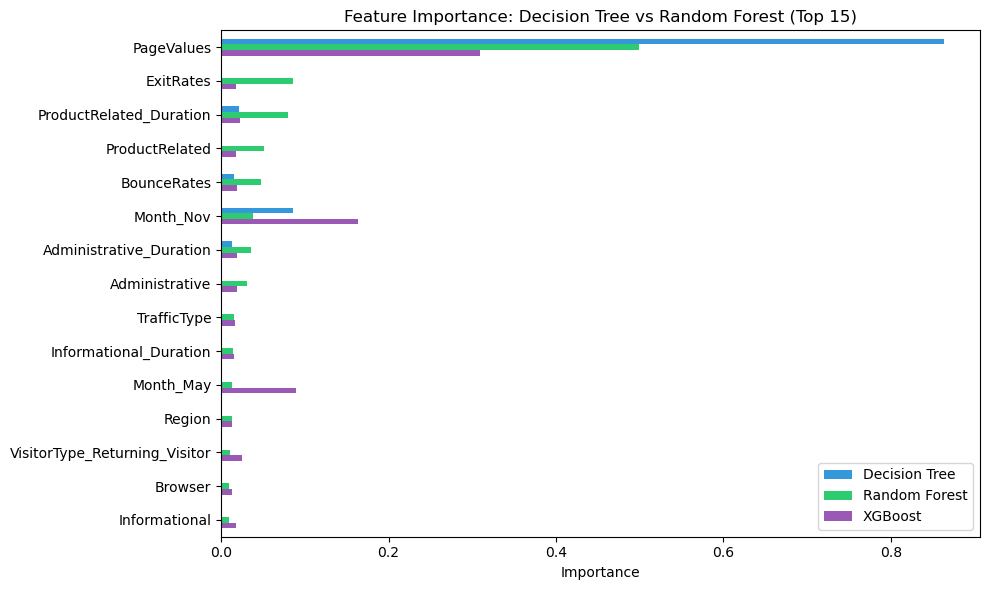

In [22]:
fi_compare = pd.DataFrame({
    'Decision Tree' : pd.Series(dt.feature_importances_, index=feature_names),
    'Random Forest' : pd.Series(rf.feature_importances_, index=feature_names),
    'XGBoost' : pd.Series(xgb.feature_importances_, index=feature_names)
}).sort_values('Random Forest', ascending=False).head(15)

fi_compare.plot(kind='barh', figsize=(10, 6), color=['#3498db','#2ecc71', '#9b59b6'])
plt.gca().invert_yaxis()
plt.title('Feature Importance: Decision Tree vs Random Forest (Top 15)')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

### Feature Importance Interpretation

The most important features include PageValues, ExitRates, and ProductRelated.

This suggests that how users interact with the website strongly influences whether they make a purchase.

From a business perspective, these results can guide website optimisation strategies to improve conversion rates.

---
## 9. K-Nearest Neighbours (KNN)

KNN is **supervised** — it uses the Revenue labels from the training data and classifies each test shopper by looking at the labels of the nearest training examples in feature space.
Because distance matters, we use the **scaled** feature matrix and tune `n_neighbors`, `weights`, and distance metric settings with **GridSearchCV**.


=== K-Nearest Neighbours — GridSearchCV ===
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Best params : {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
Best CV F1  : 0.4644

  K-Nearest Neighbours
  K-Fold CV F1  : 0.4644  ±  0.0355
  Per-fold F1   : [np.float64(0.521), np.float64(0.429), np.float64(0.423), np.float64(0.473), np.float64(0.475)]
  Test Accuracy : 0.8681
  Test F1       : 0.4937

              precision    recall  f1-score   support

 No Purchase       0.90      0.95      0.92      2059
    Purchase       0.62      0.41      0.49       382

    accuracy                           0.87      2441
   macro avg       0.76      0.68      0.71      2441
weighted avg       0.85      0.87      0.86      2441



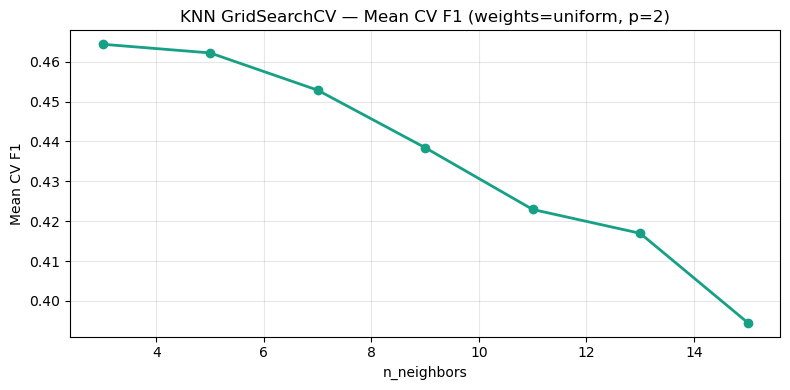

In [23]:
print('=== K-Nearest Neighbours — GridSearchCV ===')

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={
        'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'weights'    : ['uniform', 'distance'],
        'p'          : [1, 2]
    },
    cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
grid_knn.fit(X_train_sc, y_train)
print(f'\nBest params : {grid_knn.best_params_}')
print(f'Best CV F1  : {grid_knn.best_score_:.4f}')

knn, pred_knn, acc_knn, f1_knn = full_evaluation(
    'K-Nearest Neighbours',
    grid_knn.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

knn_res = pd.DataFrame(grid_knn.cv_results_)
best_weights = grid_knn.best_params_['weights']
best_p = grid_knn.best_params_['p']
plot_df = knn_res[
    (knn_res['param_weights'] == best_weights) &
    (knn_res['param_p'].astype(int) == best_p)
].sort_values('param_n_neighbors')

plt.figure(figsize=(8, 4))
plt.plot(plot_df['param_n_neighbors'].astype(int), plot_df['mean_test_score'],
         marker='o', color='#16a085', linewidth=2)
plt.xlabel('n_neighbors')
plt.ylabel('Mean CV F1')
plt.title(f'KNN GridSearchCV — Mean CV F1 (weights={best_weights}, p={best_p})')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### KNN Interpretation

Although KNN achieved reasonable accuracy, its F1-score and recall were lower than stronger models.

This means it was less effective at identifying actual buyers, making it less suitable for business situations where missing buyers can reduce revenue.

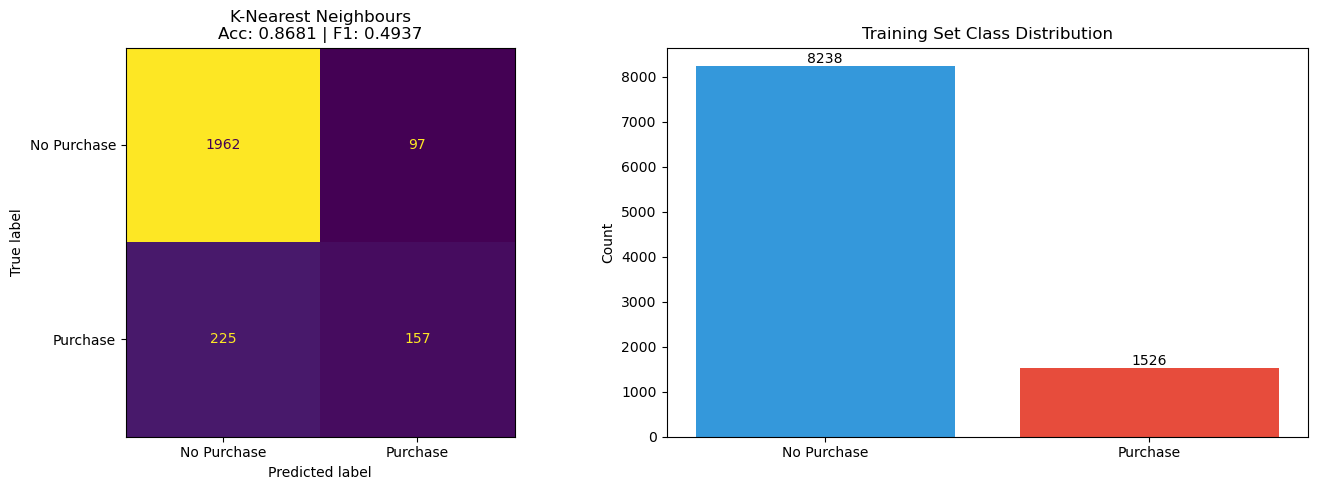

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, pred_knn), display_labels=['No Purchase','Purchase']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'K-Nearest Neighbours\nAcc: {acc_knn:.4f} | F1: {f1_knn:.4f}')

# Class balance reminder for interpretation
class_counts = y_train.value_counts().sort_index()
axes[1].bar(['No Purchase', 'Purchase'], class_counts.values, color=['#3498db', '#e74c3c'])
axes[1].set_title('Training Set Class Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout(); plt.show()


---
## 10. Overall Model Comparison


Comparing all models shows that ensemble methods such as Random Forest and XGBoost performed better overall than simpler models.

This suggests that more advanced models are better able to capture complex patterns in online customer behaviour.

=== Final Leaderboard ===
                      Test Accuracy  Test F1  CV F1 (mean)
Random Forest                0.8816   0.6771        0.6741
SVM — RBF                    0.8816   0.6690        0.6577
LR — L1                      0.8865   0.6634        0.6557
XGBoost                      0.8746   0.6615        0.6739
SVM — Linear                 0.8751   0.6554        0.6533
Decision Tree                0.8476   0.6388        0.6306
LR — No Reg                  0.8513   0.6231        0.6200
LR — L2                      0.8513   0.6231        0.6200
K-Nearest Neighbours         0.8681   0.4937        0.4644


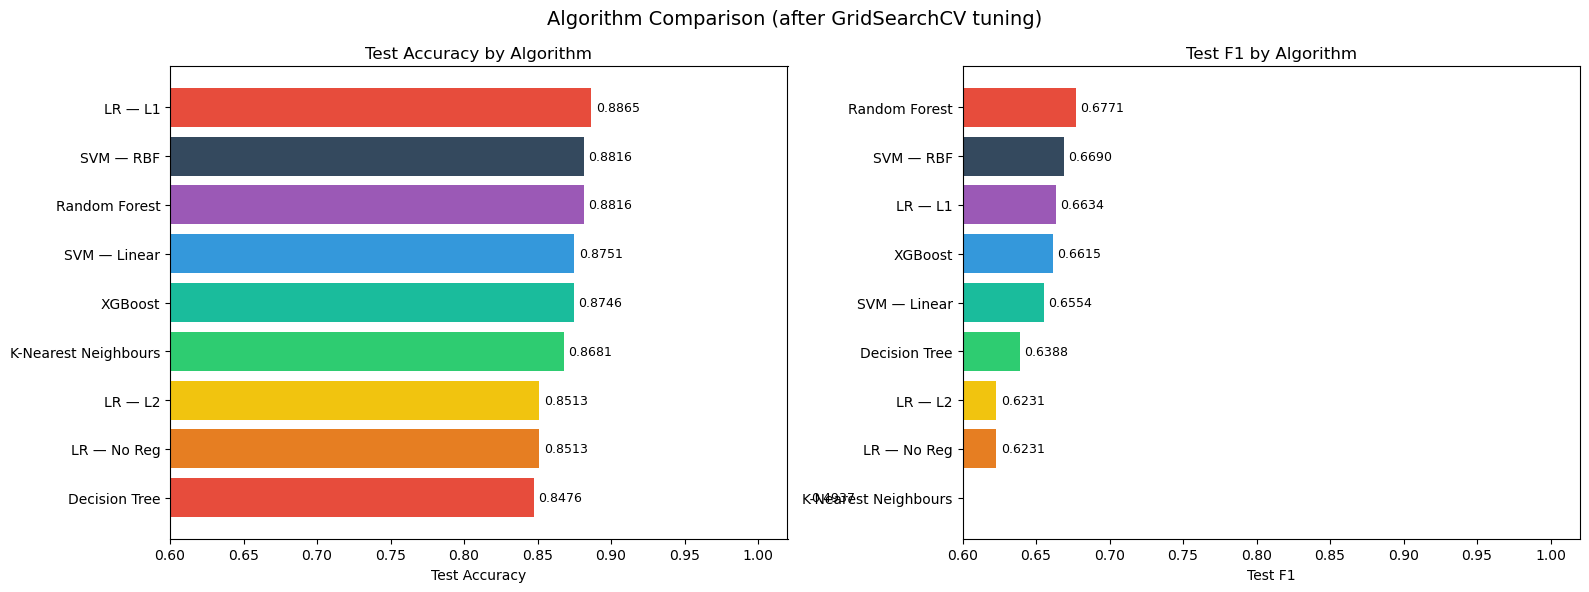

In [25]:
df_res = pd.DataFrame({
    name: {'Test Accuracy': v['test_acc'], 'Test F1': v['test_f1'], 'CV F1 (mean)': v['cv_f1']}
    for name, v in results.items()
}).T.sort_values('Test F1', ascending=False)

print('=== Final Leaderboard ===')
print(df_res.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#1abc9c','#3498db','#9b59b6','#34495e']

for ax, col, title in zip(
    axes,
    ['Test Accuracy', 'Test F1'],
    ['Test Accuracy by Algorithm', 'Test F1 by Algorithm']
):
    df_plot = df_res.sort_values(col, ascending=True)
    bars = ax.barh(df_plot.index, df_plot[col], color=palette[:len(df_plot)])
    ax.set_xlim(0.6, 1.02)
    ax.set_xlabel(col)
    ax.set_title(title, fontsize=12)
    for bar, val in zip(bars, df_plot[col]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Algorithm Comparison (after GridSearchCV tuning)', fontsize=14)
plt.tight_layout(); plt.show()

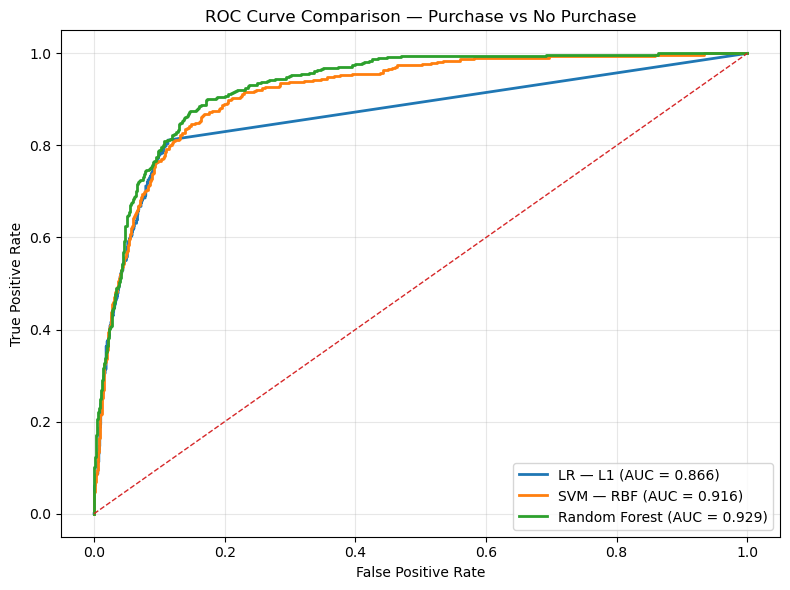

In [26]:
# ROC Curves for selected algorithms
from sklearn.metrics import roc_curve, auc

roc_models = {
    'LR — L1'         : results['LR — L1']['model'],
    'SVM — RBF'       : results['SVM — RBF']['model'],
    'Random Forest'   : results['Random Forest']['model']
}

plt.figure(figsize=(8, 6))

for name, model in roc_models.items():
    # Use probabilities where available
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_sc)[:, 1]
    else:
        y_score = model.decision_function(X_test_sc)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random guess line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Purchase vs No Purchase')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### ROC Curve Interpretation

The ROC curve shows the trade-off between true positive rate and false positive rate.

A higher AUC indicates that the model is better at distinguishing buyers from non-buyers.

This is important in business because better separation leads to more accurate targeting of high-intent users.

---
## 10. PCA on the Best Performing Algorithms

### What is PCA?
**Principal Component Analysis** reduces many features down to 2 or 3 dimensions while keeping as much of the variance (information) as possible. Each new dimension (Principal Component) is a weighted combination of the original features.

**Important correction:** PCA is a **dimensionality reduction** method. It is **not** K-Means clustering. In this notebook, the classification algorithm is **K-Nearest Neighbours (KNN)**, while PCA is only used to visualise the data and test how the best models perform after compression.

We use PCA here in two ways:
1. **Visualisation** — plot the decision boundaries of the best models in 2D PCA space
2. **Dimensionality reduction** — retrain the best models on PCA-compressed features and compare performance

The top 3 algorithms by Test F1 are selected automatically.

Top 3 algorithms by Test F1: ['Random Forest', 'SVM — RBF', 'LR — L1']


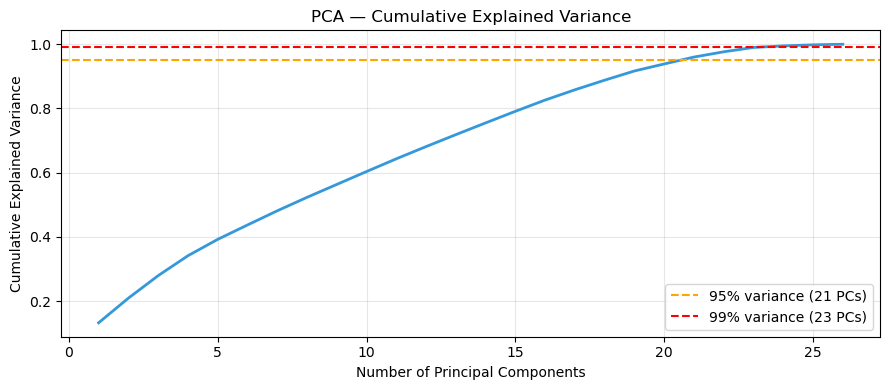

Components to explain 95% variance: 21
Components to explain 99% variance: 23
Original feature count            : 26


In [27]:
# ── Select top 3 algorithms by Test F1 ───────────────────────────────────────
top3_names = df_res['Test F1'].nlargest(3).index.tolist()
print('Top 3 algorithms by Test F1:', top3_names)

# ── PCA: explained variance curve ────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1
n_99   = np.argmax(cumvar >= 0.99) + 1

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='#3498db', linewidth=2)
plt.axhline(0.95, color='orange', linestyle='--', label=f'95% variance ({n_95} PCs)')
plt.axhline(0.99, color='red',    linestyle='--', label=f'99% variance ({n_99} PCs)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Components to explain 95% variance: {n_95}')
print(f'Components to explain 99% variance: {n_99}')
print(f'Original feature count            : {X_train_sc.shape[1]}')

### PCA Performance Interpretation

As the number of components increases, the model retains more information and performance improves.

This shows that dimensionality reduction can be useful, but too much reduction may lead to loss of predictive power.

Variance captured by 2 PCs: 20.93%


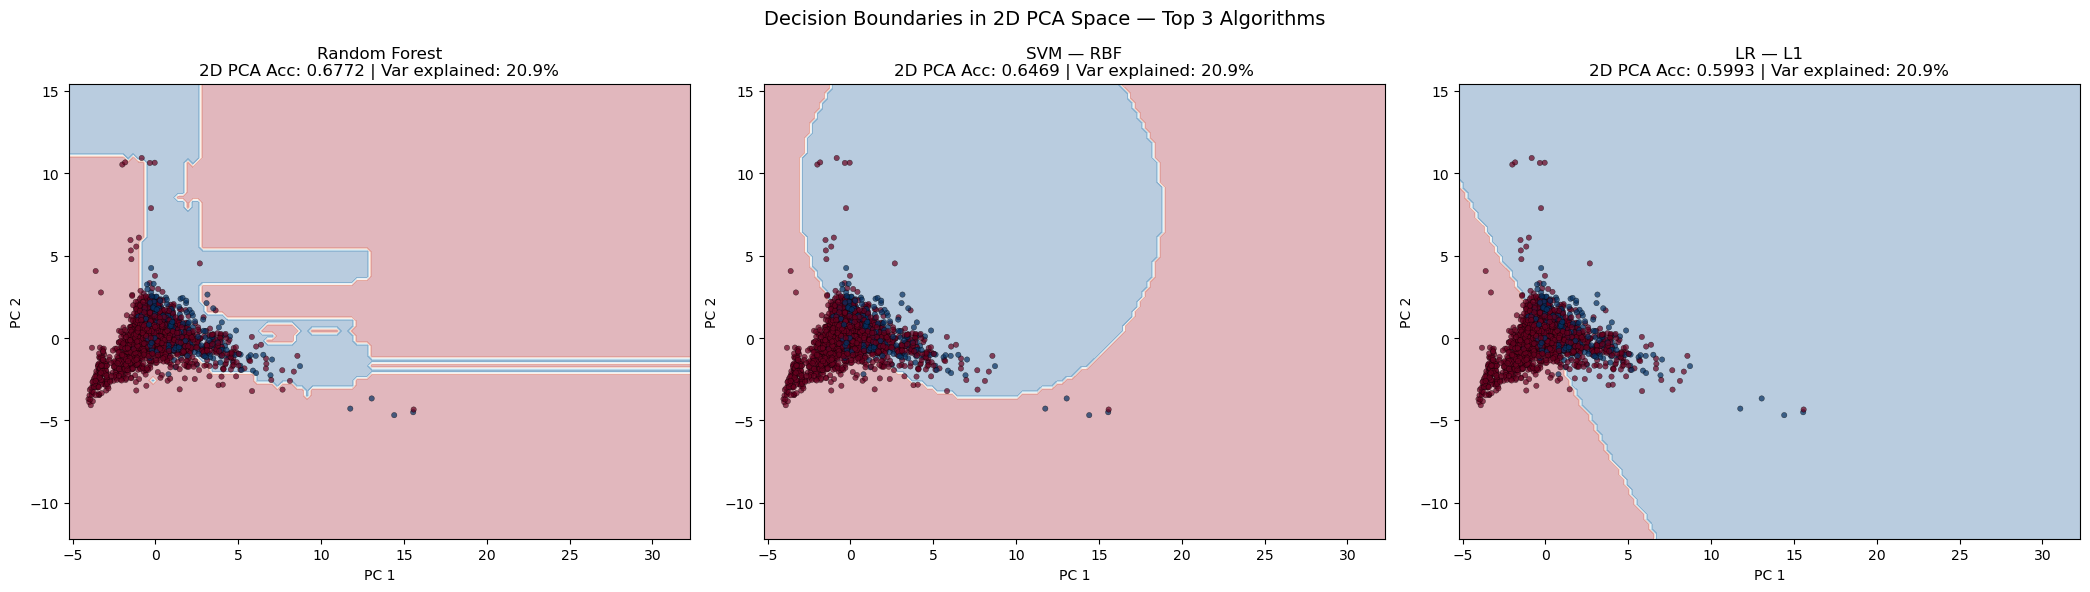

In [28]:
import copy

# ── Save a clean copy of each top-3 model BEFORE the PCA visualisation mutates them ──
top3_models_original = {name: copy.deepcopy(results[name]['model']) for name in top3_names}

# ── 2D PCA projection — decision boundary visualisation ──────────────────────
pca_2d       = PCA(n_components=2, random_state=42)
X_train_2d   = pca_2d.fit_transform(X_train_sc)
X_test_2d    = pca_2d.transform(X_test_sc)
var_2d       = pca_2d.explained_variance_ratio_.sum()
print(f'Variance captured by 2 PCs: {var_2d:.2%}')

# Mesh grid for decision boundary
h    = 0.3
x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, name in zip(axes, top3_names):
    # Re-fit a COPY on 2D PCA data (does not touch the saved originals)
    m = copy.deepcopy(top3_models_original[name])
    m.fit(X_train_2d, y_train)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    scatter = ax.scatter(
        X_test_2d[:,0], X_test_2d[:,1],
        c=y_test, cmap='RdBu', edgecolors='k', linewidths=0.3, s=15, alpha=0.7
    )
    pca_acc = accuracy_score(y_test, m.predict(X_test_2d))
    ax.set_title(f'{name}\n2D PCA Acc: {pca_acc:.4f} | Var explained: {var_2d:.1%}')
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')

plt.suptitle('Decision Boundaries in 2D PCA Space — Top 3 Algorithms', fontsize=14)
plt.tight_layout(); plt.show()


### PCA Loadings Interpretation

The loadings show which original features contribute most strongly to the principal components.

This helps us understand which variables are driving variation in the dataset, even after dimensionality reduction.

F1 Score vs Number of PCA Components:
    Random Forest  SVM — RBF  LR — L1  n_components
2          0.4021     0.4063   0.3985           NaN
5          0.4816     0.4446   0.3985           NaN
10         0.4994     0.4463   0.3985           NaN
20         0.5964     0.6651   0.4764           NaN
21         0.6084     0.6644   0.4764           NaN
23         0.5875     0.6674   0.4764           NaN
26         0.6771     0.6690   0.6634          26.0


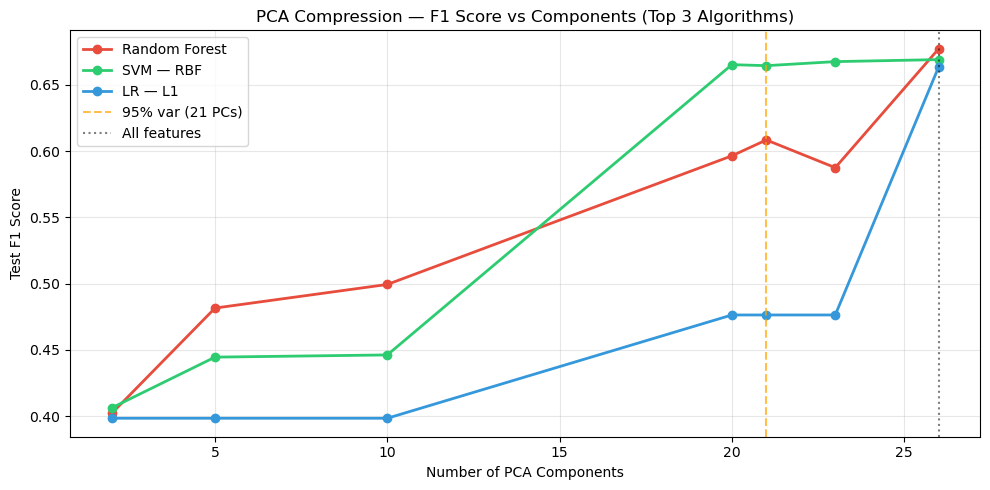

In [29]:
# ── PCA dimensionality reduction: performance at different PC counts ───────────


pc_counts = sorted(set([n for n in [2, 5, 10, 20, n_95, n_99] if n < X_train_sc.shape[1]] + [X_train_sc.shape[1]]))
pc_counts    = [2, 5, 10, 20, n_95, n_99]
pc_counts    = sorted(set(pc_counts))   # deduplicate
pca_results  = {name: [] for name in top3_names}

for n_pc in pc_counts:
    pca_n       = PCA(n_components=n_pc, random_state=42)
    X_tr_pca    = pca_n.fit_transform(X_train_sc)
    X_te_pca    = pca_n.transform(X_test_sc)

    for name in top3_names:
        # Use a copy so original models are not mutated
        m       = copy.deepcopy(top3_models_original[name])
        m.fit(X_tr_pca, y_train)
        y_p     = m.predict(X_te_pca)
        pca_results[name].append(f1_score(y_test, y_p))

df_pca_perf = pd.DataFrame(pca_results, index=pc_counts)
df_pca_perf.index.name = 'n_components'

# Add baseline (full features)
baseline_row = {name: results[name]['test_f1'] for name in top3_names}
baseline_row['n_components'] = X_train_sc.shape[1]
df_pca_perf = pd.concat([
    df_pca_perf,
    pd.DataFrame(baseline_row, index=[X_train_sc.shape[1]])
]).sort_index()

print('F1 Score vs Number of PCA Components:')
print(df_pca_perf.round(4).to_string())

plt.figure(figsize=(10, 5))
colors_pca = ['#e74c3c','#2ecc71','#3498db']
for col, c in zip(top3_names, colors_pca):
    plt.plot(df_pca_perf.index, df_pca_perf[col], marker='o', label=col, color=c, linewidth=2)

plt.axvline(n_95, color='orange', linestyle='--', alpha=0.7, label=f'95% var ({n_95} PCs)')
plt.axvline(X_train_sc.shape[1], color='black', linestyle=':', alpha=0.5, label='All features')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test F1 Score')
plt.title('PCA Compression — F1 Score vs Components (Top 3 Algorithms)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


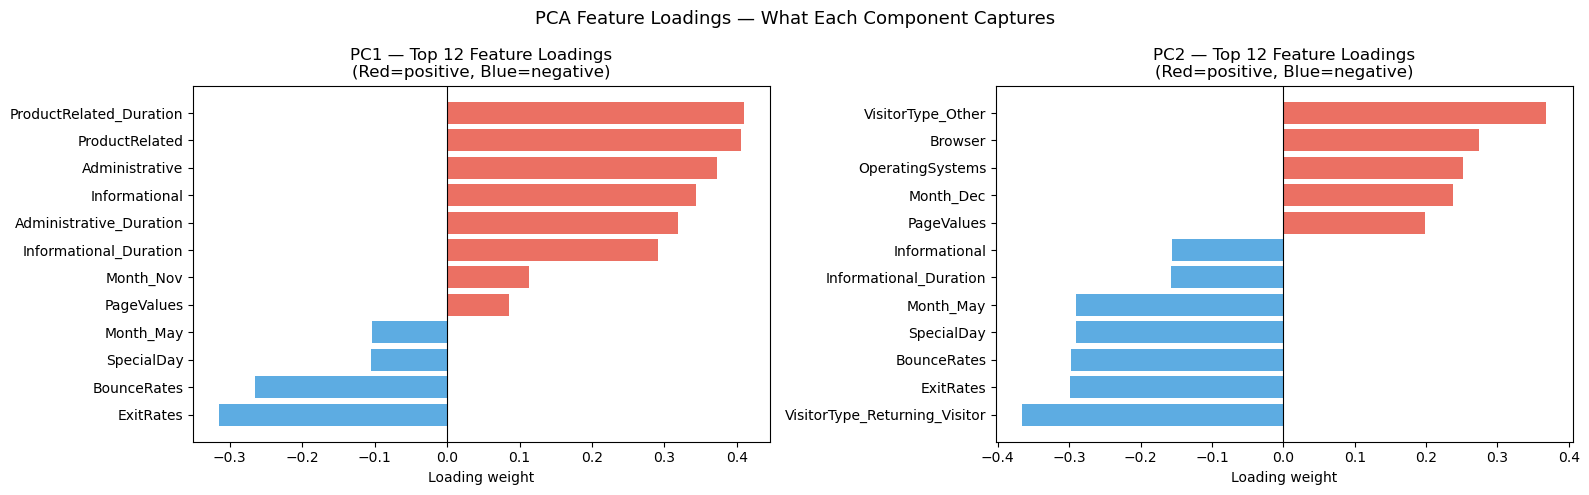

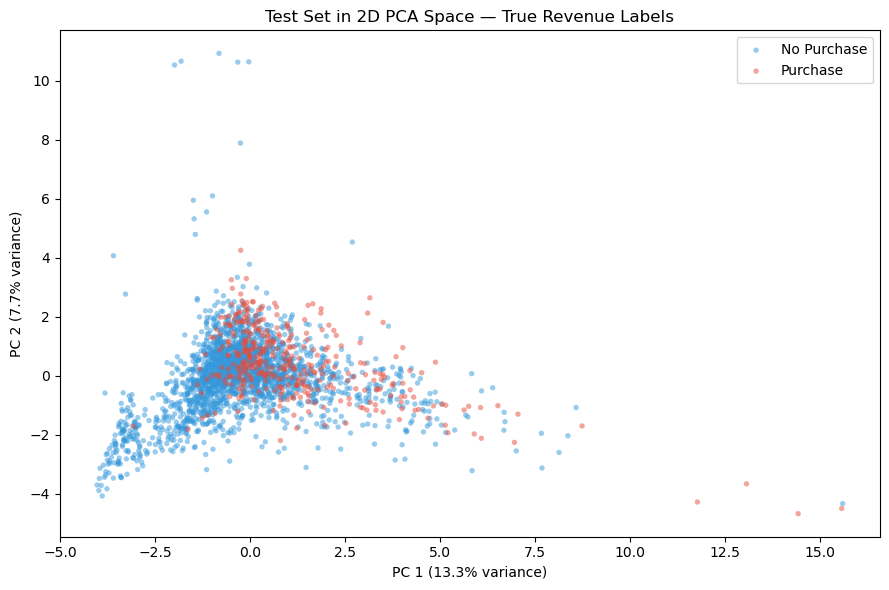

In [30]:
# ── PC1 / PC2 loadings — what drives each principal component? ────────────────
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_names,
    columns=['PC1','PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, pc in zip(axes, ['PC1','PC2']):
    top_load = loadings[pc].abs().nlargest(12).index
    vals     = loadings.loc[top_load, pc].sort_values()
    colors   = ['#e74c3c' if v > 0 else '#3498db' for v in vals]
    ax.barh(vals.index, vals.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} — Top 12 Feature Loadings\n(Red=positive, Blue=negative)')
    ax.set_xlabel('Loading weight')

plt.suptitle('PCA Feature Loadings — What Each Component Captures', fontsize=13)
plt.tight_layout(); plt.show()

# ── 2D PCA scatter — true labels ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for label, colour, name in zip([0,1], ['#3498db','#e74c3c'], ['No Purchase','Purchase']):
    mask = y_test.values == label
    ax.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        c=colour, label=name, alpha=0.5, s=15, edgecolors='none'
    )
ax.set_xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Test Set in 2D PCA Space — True Revenue Labels')
ax.legend()
plt.tight_layout(); plt.show()

---
## 11. Retrain Top 3 Algorithms on Full Feature Set (Post-PCA)

After the PCA section, the model objects stored in `results` were mutated — they were
re-fitted on PCA-compressed data for visualisation purposes. This section restores each
of the top 3 algorithms to its **best hyperparameters** and retrains it on the **original
scaled features** (no dimensionality reduction), so the final models are in their correct state.

This ensures that:
- The stored models accurately reflect full-feature performance
- Any downstream inference or export uses properly trained models
- The final leaderboard comparison is valid


In [31]:
# ── Section 11: Retrain top 3 models on PCA-reduced feature set ──────────────
print('=' * 72)
print('  RETRAINING TOP 3 MODELS ON PCA-REDUCED FEATURE SET')
print('=' * 72)

from sklearn.pipeline import Pipeline
from sklearn.base import clone
import copy

full_n = X_train_sc.shape[1]
reduced_candidates = [n for n in df_pca_perf.index if n < full_n]

pca_retrain_results = {}

for name in top3_names:
    # choose best reduced number of PCA components for this model
    best_n = int(df_pca_perf.loc[reduced_candidates, name].astype(float).idxmax())

    pca_final = PCA(n_components=best_n, random_state=42)
    X_train_red = pca_final.fit_transform(X_train_sc)
    X_test_red = pca_final.transform(X_test_sc)

    model_red = copy.deepcopy(top3_models_original[name])
    model_red.fit(X_train_red, y_train)
    y_pred_red = model_red.predict(X_test_red)

    acc_r = accuracy_score(y_test, y_pred_red)
    f1_r = f1_score(y_test, y_pred_red)

    # leakage-safe CV
    pipe = Pipeline([
        ('pca', PCA(n_components=best_n, random_state=42)),
        ('model', clone(top3_models_original[name]))
    ])
    cv_r = cross_val_score(pipe, X_train_sc, y_train, cv=skf, scoring='f1')

    print(f'\n{name}')
    print(f'  PCA components : {best_n}/{full_n}')
    print(f'  K-Fold CV F1   : {cv_r.mean():.4f} ± {cv_r.std():.4f}')
    print(f'  Test Accuracy  : {acc_r:.4f}')
    print(f'  Test F1        : {f1_r:.4f}')
    print(classification_report(y_test, y_pred_red, target_names=['No Purchase', 'Purchase']))

    results[name]['model'] = model_red
    results[name]['pca'] = pca_final
    results[name]['n_components'] = best_n
    results[name]['y_pred'] = y_pred_red
    results[name]['test_acc'] = acc_r
    results[name]['test_f1'] = f1_r
    results[name]['cv_f1'] = cv_r.mean()

    pca_retrain_results[name] = {
        'original_f1': df_res.loc[name, 'Test F1'],
        'pca_f1': f1_r,
        'original_acc': df_res.loc[name, 'Test Accuracy'],
        'pca_acc': acc_r,
        'pca_components': best_n
    }

print('\nAll top-3 models successfully retrained on PCA-reduced feature sets.')

  RETRAINING TOP 3 MODELS ON PCA-REDUCED FEATURE SET

Random Forest
  PCA components : 21/26
  K-Fold CV F1   : 0.5890 ± 0.0195
  Test Accuracy  : 0.8734
  Test F1        : 0.6084
              precision    recall  f1-score   support

 No Purchase       0.93      0.92      0.92      2059
    Purchase       0.59      0.63      0.61       382

    accuracy                           0.87      2441
   macro avg       0.76      0.77      0.77      2441
weighted avg       0.88      0.87      0.88      2441


SVM — RBF
  PCA components : 23/26
  K-Fold CV F1   : 0.6579 ± 0.0244
  Test Accuracy  : 0.8812
  Test F1        : 0.6674
              precision    recall  f1-score   support

 No Purchase       0.95      0.90      0.93      2059
    Purchase       0.59      0.76      0.67       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.80      2441
weighted avg       0.90      0.88      0.89      2441


LR — L1
  PCA components : 20/26
  K-Fold 

Full Features vs PCA-Reduced Comparison:
               original_f1  pca_f1  original_acc  pca_acc  pca_components
Algorithm                                                                
Random Forest       0.6771  0.6084        0.8816   0.8734            21.0
SVM — RBF           0.6690  0.6674        0.8816   0.8812            23.0
LR — L1             0.6634  0.4764        0.8865   0.7091            20.0


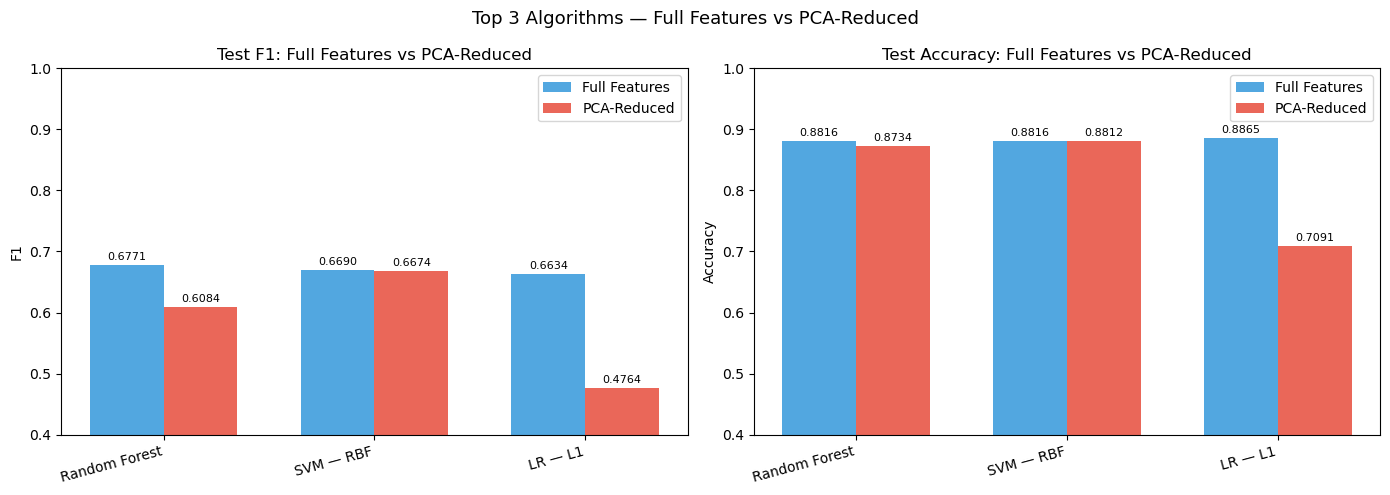

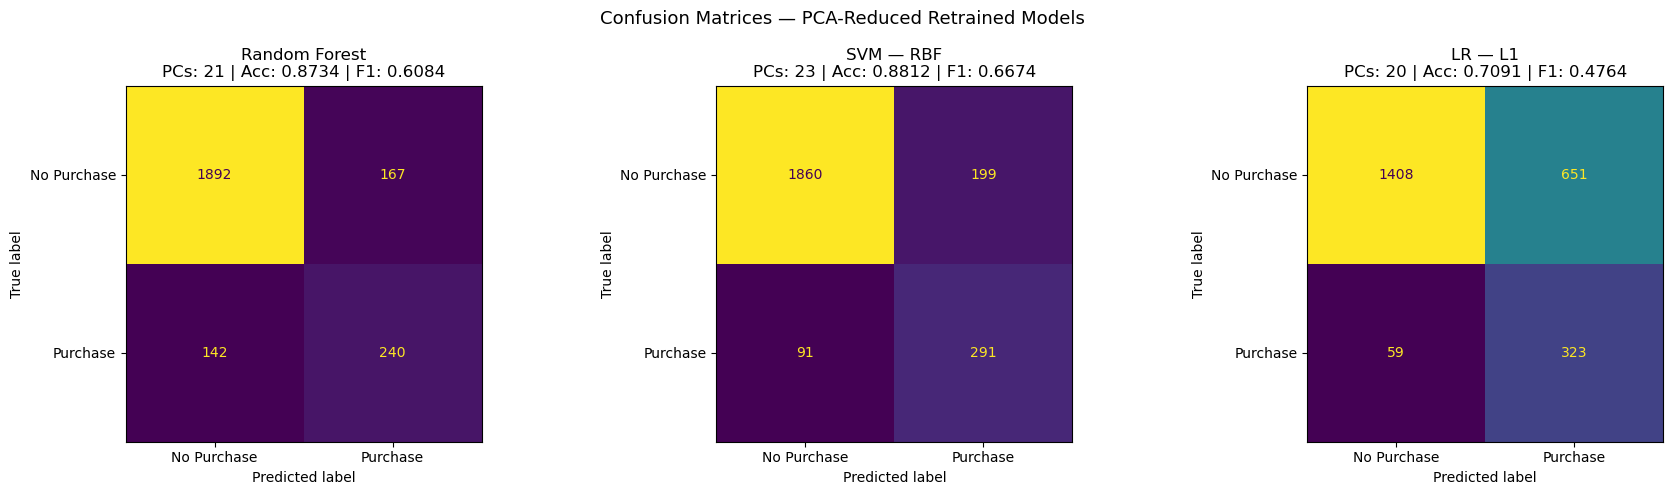

In [32]:
# ── Compare original full-feature vs PCA-reduced performance ─────────────────
compare_df = pd.DataFrame(pca_retrain_results).T
compare_df.index.name = 'Algorithm'

print('Full Features vs PCA-Reduced Comparison:')
print(compare_df.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(top3_names))
w = 0.35

for ax, metric, orig_col, pca_col, title in zip(
    axes,
    ['F1', 'Accuracy'],
    ['original_f1', 'original_acc'],
    ['pca_f1', 'pca_acc'],
    ['Test F1: Full Features vs PCA-Reduced', 'Test Accuracy: Full Features vs PCA-Reduced']
):
    orig_vals = [pca_retrain_results[n][orig_col] for n in top3_names]
    pca_vals = [pca_retrain_results[n][pca_col] for n in top3_names]

    bars1 = ax.bar(x - w/2, orig_vals, w, label='Full Features', color='#3498db', alpha=0.85)
    bars2 = ax.bar(x + w/2, pca_vals, w, label='PCA-Reduced', color='#e74c3c', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(top3_names, rotation=15, ha='right')
    ax.set_ylim(0.4, 1.0)
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Top 3 Algorithms — Full Features vs PCA-Reduced', fontsize=13)
plt.tight_layout()
plt.show()

# Confusion matrices for PCA-retrained models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name in zip(axes, top3_names):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, results[name]['y_pred']),
        display_labels=['No Purchase', 'Purchase']
    ).plot(ax=ax, colorbar=False)
    ax.set_title(
        f'{name}\nPCs: {results[name]["n_components"]} | '
        f'Acc: {results[name]["test_acc"]:.4f} | F1: {results[name]["test_f1"]:.4f}'
    )

plt.suptitle('Confusion Matrices — PCA-Reduced Retrained Models', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| Algorithm | Type | Tuned With | Key Strength |
|---|---|---|---|
| LR — No Reg | Linear | — | Interpretable baseline |
| LR — L1 | Linear | GridSearchCV | Feature selection (zeros coefficients) |
| LR — L2 | Linear | GridSearchCV | Robust shrinkage |
| SVM Linear | Linear | GridSearchCV | Max-margin linear boundary |
| SVM RBF | Non-linear | GridSearchCV | Captures complex patterns |
| Decision Tree | Non-linear | GridSearchCV | Interpretable, visualisable |
| Random Forest | Ensemble | GridSearchCV | Reduces variance via averaging trees |
| XGBoost | Ensemble | GridSearchCV | Corrects errors sequentially — often best |
| K-Nearest Neighbours | Supervised | GridSearchCV | Simple distance-based classification |

### PCA Takeaways
- **PCA is not K-Means** — it reduces dimensions, while **KNN** is the classifier used in this notebook
- **Decision boundary plots** show how each algorithm separates classes in 2D — useful for understanding linearity
- **F1 vs components curve** shows how much information can be compressed away before performance degrades
- **Loading plots** reveal which original features drive each principal component — connecting dimensionality reduction back to the raw data
- A large gap between 2D-PCA accuracy and full-feature accuracy means the class boundary is genuinely high-dimensional and cannot be easily visualised
